In [1]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000

data = Data()
data.generate(n=N, seed=42)
data.generate_random_condition()

('feature_6 > -0.20284697064188606', 0.584)

# CT on D

Total options: 152


<Axes: xlabel='depth'>

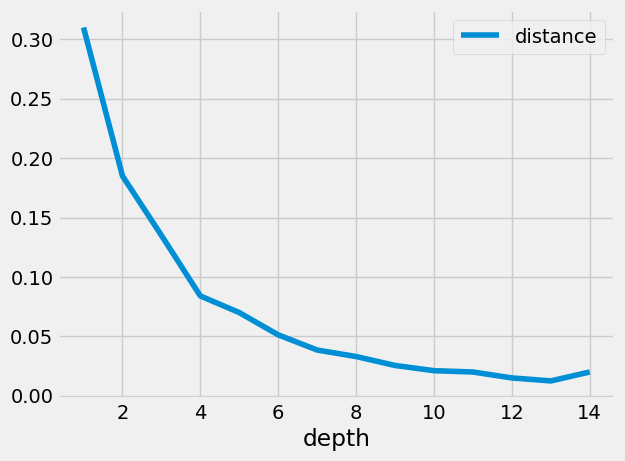

In [2]:
ct_D = CT(data, on = "D")
ct_D.fit(max_depth=None)
ct_D.parse_tree(max_depth=100000)
x1 = pd.DataFrame(ct_D.scores)
print('Total options:', x1.shape[0])
x1.groupby("depth").agg({"distance": "mean"}).plot()

<Axes: xlabel='depth'>

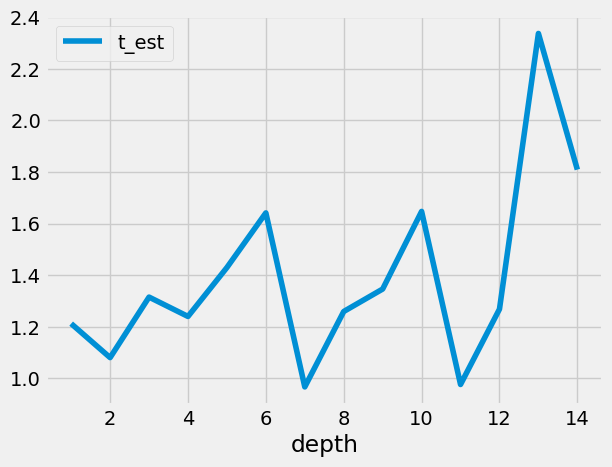

In [3]:
x1.groupby("depth").agg({"t_est": "mean"}).plot()

depth: 4 options: 22
depth: 5 options: 34
depth: 6 options: 50
depth: 7 options: 70
depth: 8 options: 90
depth: 9 options: 110
depth: 10 options: 128
depth: 11 options: 136
depth: 12 options: 146
depth: 13 options: 150


Text(0.5, 1.0, 'Number of options by max_depth')

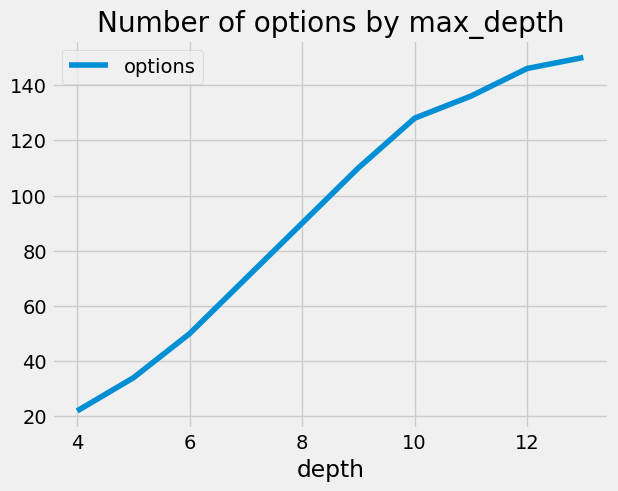

In [4]:
dic = []
for max_depth in range(4,14):
    ct_D = CT(data, on = "D")
    ct_D.fit(max_depth=max_depth)
    ct_D.parse_tree(max_depth=max_depth)
    x1 = pd.DataFrame(ct_D.scores)
    dic.append({"depth": x1['depth'].max(), "options": x1.shape[0]})
    print("depth:", x1['depth'].max(), "options:", x1.shape[0])

x = pd.DataFrame(dic)
x.plot(x="depth", y="options")
plt.title("Number of options by max_depth")

# CT on P

Total options: 88


<Axes: xlabel='depth'>

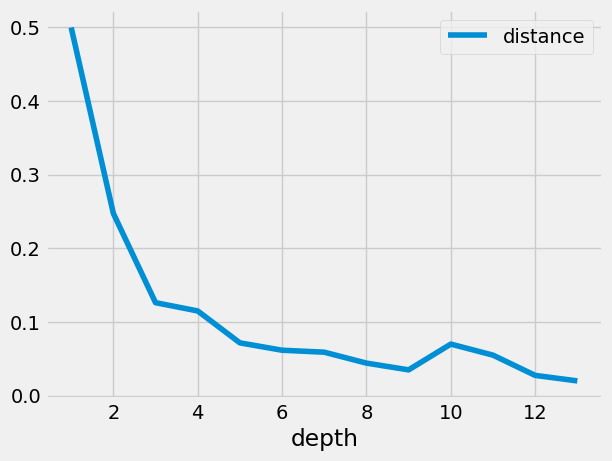

In [5]:
ct_P = CT(data, on = "P")
ct_P.fit(max_depth=None)
ct_P.parse_tree(max_depth=100000)
x2 = pd.DataFrame(ct_P.scores)
print('Total options:', x2.shape[0])

x2.groupby("depth").agg({"distance": "mean"}).plot()

<Axes: xlabel='depth'>

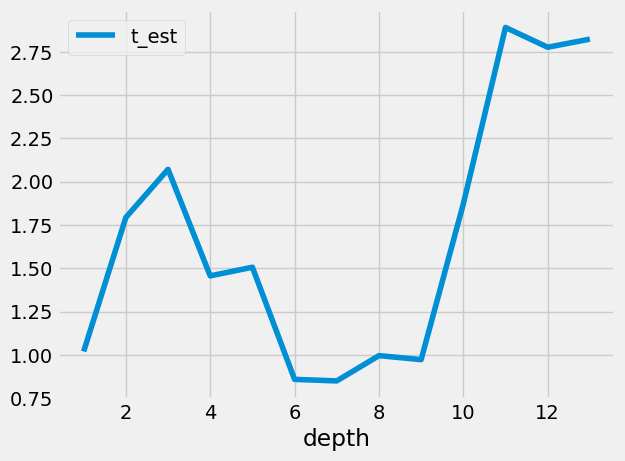

In [6]:
x2.groupby("depth").agg({"t_est": "mean"}).plot()

depth: 4 options: 22
depth: 5 options: 34
depth: 6 options: 46
depth: 7 options: 56
depth: 8 options: 68
depth: 9 options: 78
depth: 10 options: 80
depth: 11 options: 82
depth: 12 options: 86
depth: 13 options: 88


Text(0.5, 1.0, 'Number of options by max_depth')

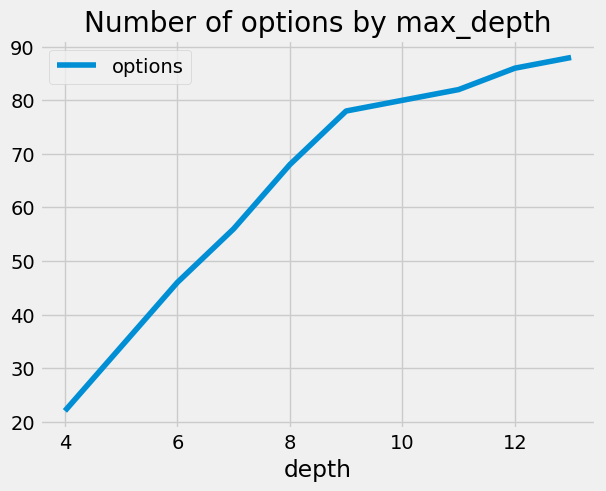

In [7]:
dic = []
for max_depth in range(4,14):
    ct_D = CT(data, on = "P")
    ct_D.fit(max_depth=max_depth)
    ct_D.parse_tree(max_depth=max_depth)
    x1 = pd.DataFrame(ct_D.scores)
    dic.append({"depth": x1['depth'].max(), "options": x1.shape[0]})
    print("depth:", x1['depth'].max(), "options:", x1.shape[0])

x = pd.DataFrame(dic)
x.plot(x="depth", y="options")
plt.title("Number of options by max_depth")

# CF

Total options: 1121


<Axes: xlabel='depth'>

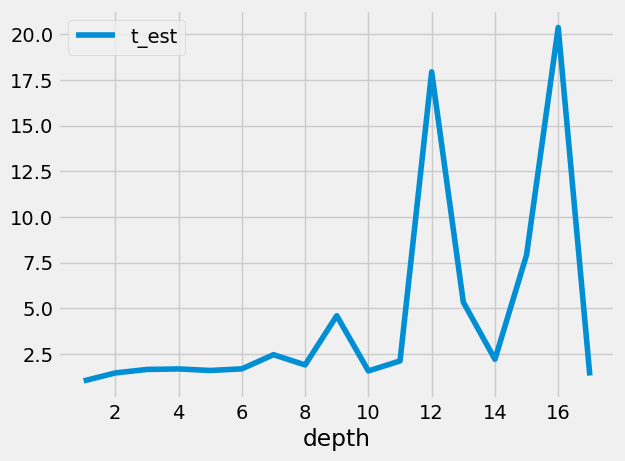

In [8]:
cf_mse = CF(data)
cf_mse.fit(criterion="mse", n_estimators=100, max_depth=None)
cf_mse.parse_forest(max_depth=1000)  

x3 = pd.DataFrame(cf_mse.scores)
print('Total options:', x3.shape[0])

x3.groupby("depth").agg({"t_est": "mean"}).plot()

<Axes: xlabel='depth'>

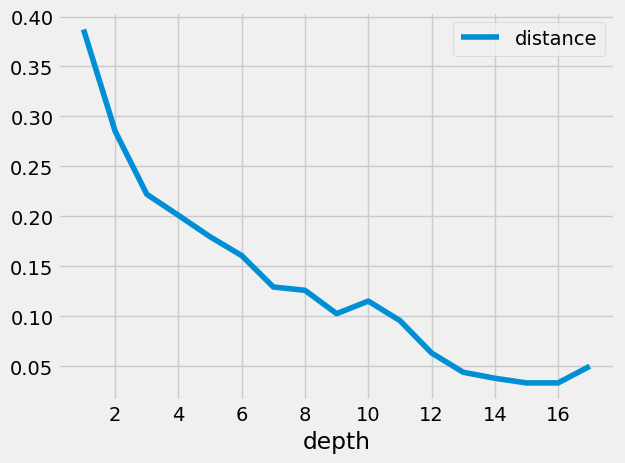

In [9]:
x3.groupby("depth").agg({"distance": "mean"}).plot()

  7%|▋         | 1/14 [00:09<02:00,  9.27s/it]

depth: 4 options: 785


 14%|█▍        | 2/14 [00:24<02:33, 12.78s/it]

depth: 5 options: 953


 21%|██▏       | 3/14 [00:42<02:44, 14.98s/it]

...

 93%|█████████▎| 13/14 [09:19<01:04, 64.12s/it]

depth: 15 options: 1238


100%|██████████| 14/14 [10:31<00:00, 45.14s/it]

depth: 17 options: 1163


Text(0.5, 1.0, 'Number of options by max_depth')

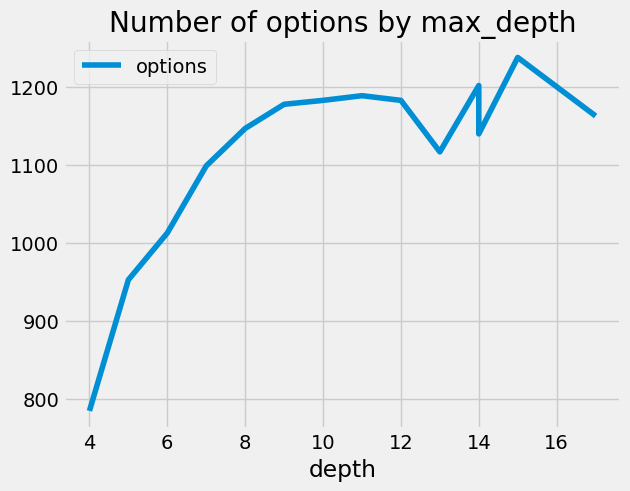

In [11]:
from tqdm import tqdm
dic = []
for max_depth in tqdm(range(4,18)):
    cf_mse = CF(data)
    cf_mse.fit(criterion="mse", max_depth=max_depth, n_estimators=100)
    cf_mse.parse_forest(max_depth=max_depth)  
    x1 = pd.DataFrame(cf_mse.scores)
    dic.append({"depth": x1['depth'].max(), "options": x1.shape[0]})
    print("depth:", x1['depth'].max(), "options:", x1.shape[0])

x = pd.DataFrame(dic)
x.plot(x="depth", y="options")
plt.title("Number of options by max_depth")